# Use-case diversity and overlap — and whether it biases the ensemble

**The question.** TIRI ships one model per customer silo, but chooses what to ship
*centrally*, in a leave-one-use-case-out (LOGO) loop over the use cases we happen to have
(`CONTEXT.md` §1). That loop is only trustworthy if the held-out use case is genuinely
*new* to the training pool. If two of our use cases are near-duplicates, LOGO quietly
grades itself on a fold it has already seen, and every default chosen that way — feature
family, model class, hyperparameters — is picked on an inflated score.

So: **how similar are the use cases, and does that similarity actually inflate LOGO?**

**Two surfaces, in one map.** 6 live TIRI use cases and 28 `benchset_v1` collections.
They are directly comparable because both sides embed briefs from the same five fields
joined the same way, and both route papers through `embedding_utils.embed_papers` —
asserted in §1, not assumed. The caveats that come with that are in
`scripts/usecase_diversity_utils.py`'s docstring (benchset abstracts are truncated at
4,000 chars; benchset briefs are AI-written, live briefs are analyst-written).

**Three notions of "similar", deliberately kept apart.** They disagree, and the
disagreement is the finding:

| | What it measures | §  |
|---|---|---|
| **Corpus geometry** | do the paper clouds sit in the same place | §3, §4 |
| **Functional overlap** | does someone else's brief screen *my* corpus | §6 |
| **Transfer leakage** | does a twin in the training pool inflate my LOGO score | §9 |

**How to read every similarity number here.** Raw cosine between two embedding centroids
is not "how similar these use cases are" — every embedding of English academic prose
shares a large common direction, so unrelated corpora routinely sit at 0.7–0.9. §2
establishes the yardstick before any map is drawn. Nothing below is interpretable without it.

## 1. Setup, provenance guard, and what is in the two surfaces

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, rankdata

sys.path.insert(0, "../../scripts")
import usecase_diversity_utils as udu
from ensemble_eval_utils import logo

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)

# --- chart style -------------------------------------------------------------
# Two categorical hues only (surface identity); validated all-pairs for CVD.
SURF = {"live": "#eb6834", "benchset": "#2a78d6"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdbd6"
# Sequential = one hue light->dark (magnitude). Diverging = blue/red, gray midpoint.
SEQ = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", ["#0d366b", "#2a78d6", "#f0efec", "#e34948", "#8f1f1f"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

def offdiag(M):
    A = np.asarray(M, dtype=float)
    return A[~np.eye(len(A), dtype=bool)]

print("matplotlib", mpl.__version__)

matplotlib 3.11.1


In [2]:
# The joint map is only legitimate while both surfaces build briefs the same way.
udu.assert_surfaces_comparable()
print("brief recipe identical across surfaces: OK")

# One full pass over the 2.4 GB vector cache; a no-op once written.
print(udu.build_diversity_cache().to_string(index=False))

INDEX = udu.use_case_index()
SHORT = {k: k.replace("synergy_", "").replace("_metareview", "") for k in INDEX.use_case_key}
INDEX.groupby("surface").agg(use_cases=("use_case_key", "size"), papers=("n_papers", "sum"),
                             positives=("n_pos", "sum"), prevalence=("prevalence", "median")).round(4)

brief recipe identical across surfaces: OK


   model status  n_use_cases
  jasper cached           34
  qwen4b cached           34
  qwen8b cached            6
openai3l cached            6
 gemini2 cached            6
   qzhou cached            6
nemotron cached            6
    pplx cached            6
 mistral cached            6
  bge_m3 cached            6
specter2 cached            6


,use_cases,papers,positives,prevalence
surface,,,,
benchset,28,181199,3374,0.0162
live,6,1848,1065,0.6218


The two surfaces sit in different *regimes*, which matters for everything downstream: the
live pools run 26–77% positive, the benchset 0.2–22%. `CONTEXT.md` §3 already flags this —
every F2 number measured on the live pools was measured at ~20x production prevalence.
Keep it in view: prevalence turns out to be the strongest single predictor of LOGO
transfer in §9, ahead of any similarity measure.

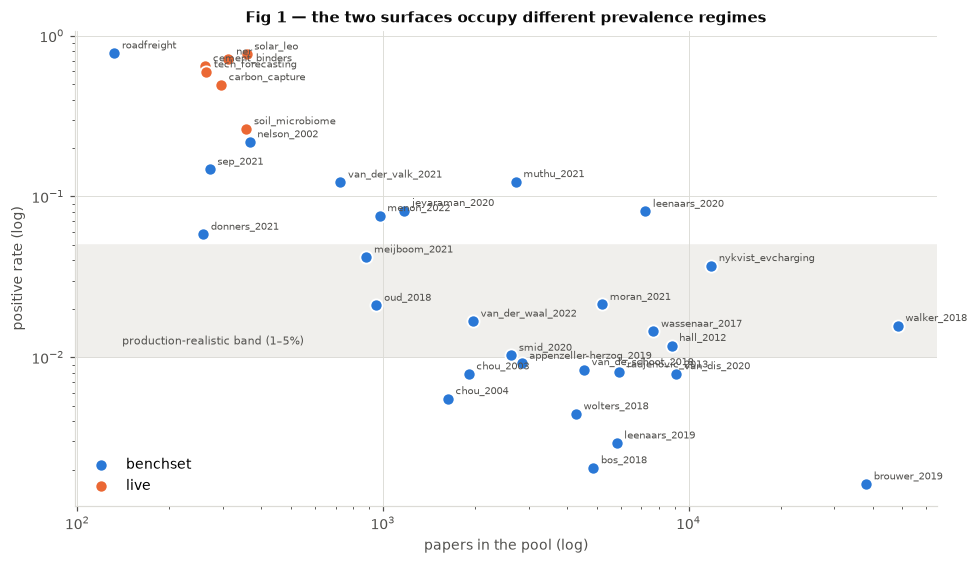

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.2))
for surface, grp in INDEX.groupby("surface"):
    ax.scatter(grp.n_papers, grp.prevalence, s=64, color=SURF[surface], label=surface,
               edgecolors="white", linewidths=1.2, zorder=3)
for _, r in INDEX.iterrows():
    ax.annotate(SHORT[r.use_case_key], (r.n_papers, r.prevalence), fontsize=6.5,
                color=INK2, xytext=(5, 3), textcoords="offset points")
ax.set(xscale="log", yscale="log", xlabel="papers in the pool (log)",
       ylabel="positive rate (log)",
       title="Fig 1 — the two surfaces occupy different prevalence regimes")
ax.axhspan(0.01, 0.05, color="#f0efec", zorder=0)
ax.annotate("production-realistic band (1–5%)", (1.4e2, 0.012), fontsize=7, color=INK2)
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 2. The yardstick — what would "identical" even score?

Before drawing a single map: a cosine of 0.70 between two use-case centroids means nothing
on its own. The honest reference is **split-half** — cut *one* use case's papers in two at
random and score the two halves against each other with the exact same statistic. That is
what "as similar as it is possible to be" looks like for this model on this data.

Everything in §3 is read against that line.

In [4]:
MODEL = "jasper"   # the bake-off's adopted model; §5 re-runs the structure on 10 others

cent = udu.load_centroids(MODEL)
sim_raw = udu.centroid_similarity(cent, center=False)
sim_cen = udu.centroid_similarity(cent, center=True)

pooled_mean = udu.stack(cent, "centroid").mean(axis=0)
sh_raw = udu.split_half_reference(MODEL)
sh_cen = udu.split_half_reference(MODEL, center_vec=pooled_mean)

ref_raw, ref_cen = sh_raw.split_half_cos.mean(), sh_cen.split_half_cos.mean()
summary = pd.DataFrame({
    "off-diagonal mean": [offdiag(sim_raw).mean(), offdiag(sim_cen).mean()],
    "off-diagonal max":  [offdiag(sim_raw).max(),  offdiag(sim_cen).max()],
    "split-half ceiling":[ref_raw, ref_cen],
}, index=["raw cosine", "mean-centred cosine"]).round(3)
summary

,off-diagonal mean,off-diagonal max,split-half ceiling
raw cosine,0.703,0.972,0.997
mean-centred cosine,-0.026,0.871,0.987


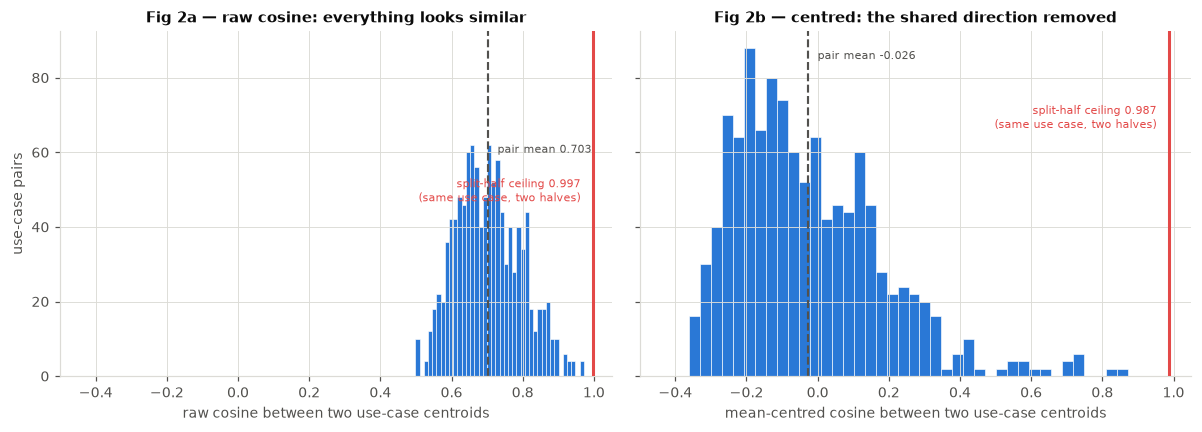

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (M, ref, name) in zip(axes, [(sim_raw, ref_raw, "raw cosine"),
                                     (sim_cen, ref_cen, "mean-centred cosine")]):
    vals = offdiag(M)
    ax.hist(vals, bins=40, color="#2a78d6", edgecolor="white", linewidth=0.4)
    ax.axvline(ref, color="#e34948", linewidth=2, zorder=5)
    ax.annotate(f"split-half ceiling {ref:.3f}\n(same use case, two halves)",
                (ref, ax.get_ylim()[1] * 0.72), fontsize=7.5, color="#e34948",
                ha="right", xytext=(-8, 0), textcoords="offset points")
    ax.axvline(vals.mean(), color=INK2, linestyle="--", linewidth=1.4)
    ax.annotate(f"pair mean {vals.mean():.3f}", (vals.mean(), ax.get_ylim()[1] * 0.92),
                fontsize=7.5, color=INK2, xytext=(6, 0), textcoords="offset points")
    ax.set(xlabel=f"{name} between two use-case centroids", xlim=(-0.5, 1.05))
axes[0].set_ylabel("use-case pairs")
axes[0].set_title("Fig 2a — raw cosine: everything looks similar")
axes[1].set_title("Fig 2b — centred: the shared direction removed")
plt.tight_layout(); plt.show()

**Read this before anything else.** On raw cosine the average pair of use cases scores
**0.70** — which sounds like "quite similar" until you see that two random halves of the
*same* use case score **0.997**. On this scale 0.70 is not "similar", it is "shares the
generic direction every academic abstract shares". Mean-centring removes that direction and
the average pair drops to about **0.0** — near-orthogonal, i.e. genuinely unrelated.

But the *max* stays high in both panels. The structure is not in the average, it is in a
handful of specific pairs. §3 finds them.

## 3. The map — who is near whom

Centred centroid cosine, hierarchically clustered. Orange labels are live TIRI use cases,
blue are benchset collections.

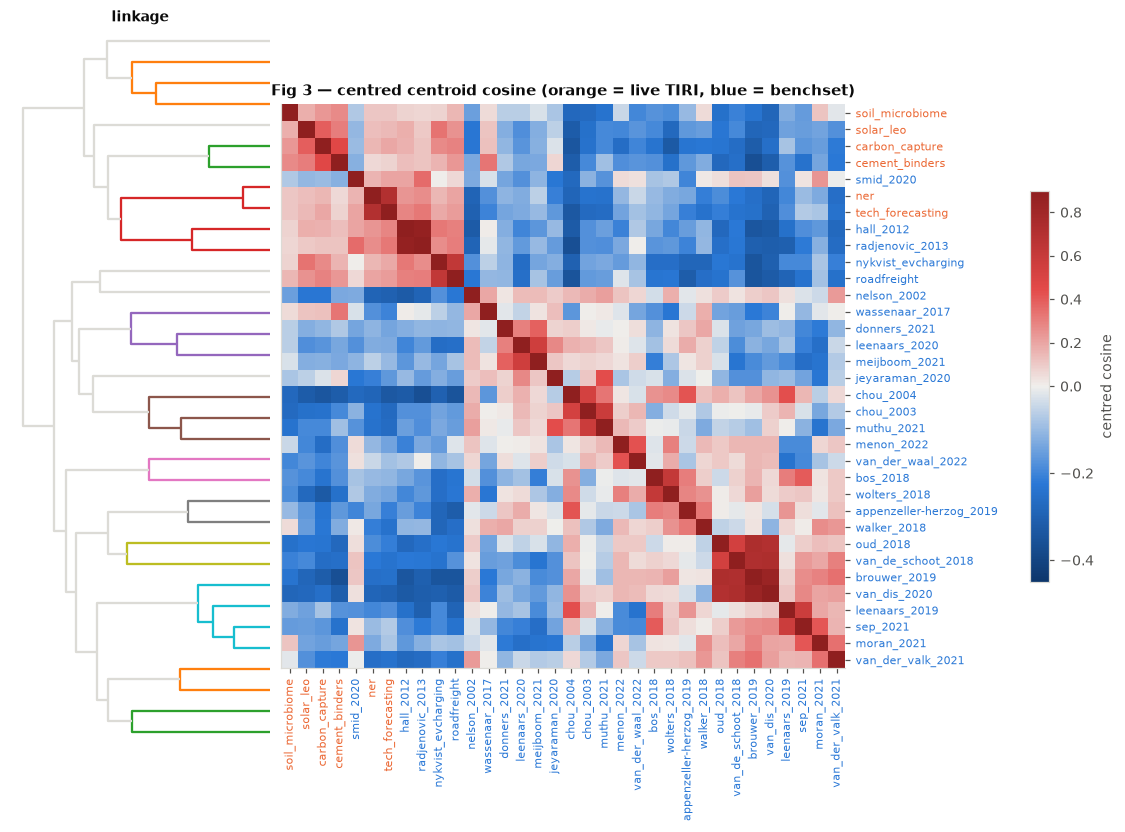

In [6]:
keys = list(sim_cen.index)
D = 1.0 - sim_cen.to_numpy()
D = (D + D.T) / 2
np.fill_diagonal(D, 0.0)
Z = linkage(squareform(D, checks=False), method="average")
order = dendrogram(Z, no_plot=True, labels=keys)["ivl"]
S = sim_cen.loc[order, order]

fig = plt.figure(figsize=(13.5, 8.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3.4], wspace=0.02)

smap = INDEX.set_index("use_case_key").surface

axd = fig.add_subplot(gs[0]); axd.grid(False)
dendrogram(Z, orientation="left", no_labels=True, ax=axd, color_threshold=0.75,
           above_threshold_color=GRID)
axd.invert_yaxis()
for s in axd.spines.values(): s.set_visible(False)
axd.set_xticks([]); axd.set_yticks([]); axd.set_title("linkage", fontsize=9)

axh = fig.add_subplot(gs[1]); axh.grid(False)
im = axh.imshow(S, cmap=DIV, norm=TwoSlopeNorm(vmin=-0.45, vcenter=0.0, vmax=0.9))
axh.set_xticks(range(len(order))); axh.set_yticks(range(len(order)))
axh.set_xticklabels([SHORT[k] for k in order], rotation=90, fontsize=7)
axh.set_yticklabels([SHORT[k] for k in order], fontsize=7)
axh.yaxis.tick_right()
for lab, k in zip(axh.get_xticklabels(), order):
    lab.set_color(SURF[smap[k]])
for lab, k in zip(axh.get_yticklabels(), order):
    lab.set_color(SURF[smap[k]])
axh.set_title("Fig 3 — centred centroid cosine (orange = live TIRI, blue = benchset)")
fig.colorbar(im, ax=axh, shrink=0.55, pad=0.21, label="centred cosine")
plt.show()

In [7]:
pairs = (sim_cen.where(~np.eye(len(sim_cen), dtype=bool)).stack()
         .rename("centred_cos").reset_index()
         .rename(columns={"level_0": "a", "level_1": "b"}))
pairs = pairs[pairs.a < pairs.b].sort_values("centred_cos", ascending=False)
pairs["raw_cos"] = [sim_raw.loc[r.a, r.b] for r in pairs.itertuples()]
pairs["surfaces"] = [f"{INDEX.set_index('use_case_key').surface[r.a][:4]}/"
                     f"{INDEX.set_index('use_case_key').surface[r.b][:4]}" for r in pairs.itertuples()]
print("Closest 10 use-case pairs  (split-half ceiling = %.3f centred)" % ref_cen)
pairs.head(10).assign(a=lambda d: d.a.map(SHORT), b=lambda d: d.b.map(SHORT)).round(3).to_string(index=False)

Closest 10 use-case pairs  (split-half ceiling = 0.987 centred)


'                 a                  b  centred_cos  raw_cos  surfaces\n         hall_2012    radjenovic_2013        0.871    0.963 benc/benc\n      brouwer_2019       van_dis_2020        0.831    0.972 benc/benc\nvan_de_schoot_2018       van_dis_2020        0.737    0.940 benc/benc\n      brouwer_2019           oud_2018        0.733    0.929 benc/benc\n      brouwer_2019 van_de_schoot_2018        0.723    0.937 benc/benc\n               ner   tech_forecasting        0.710    0.887 live/live\n          oud_2018       van_dis_2020        0.705    0.923 benc/benc\nnykvist_evcharging        roadfreight        0.632    0.847 benc/benc\n          bos_2018       wolters_2018        0.613    0.898 benc/benc\n         chou_2003         muthu_2021        0.579    0.867 benc/benc'

One pair stands out by a distance: **`hall_2012` ↔ `radjenovic_2013`**, both systematic
reviews of *software fault prediction*, published a year apart. They are not "related
topics", they are two screens of the same literature. `chou_2003 ↔ chou_2004` (same first
author, adjacent drug-comparison reviews) and a psychology cluster
(`brouwer_2019` / `van_dis_2020` / `oud_2018` / `van_de_schoot_2018`) follow.

Exactly **one live pair** makes the top ten — `ner ↔ tech_forecasting` at 0.710, both
being broadly computational — and **no live–benchset pair appears at all**. The nine
tightest pairs in the whole map are benchset-internal.

## 4. Where the clouds actually touch

A centroid is a summary of a cloud; two clouds can have distant means and still overlap
heavily at the edges. This asks the question directly: pool every use case's papers, and
for each paper count how many of its 25 nearest neighbours belong to a *different* use case.

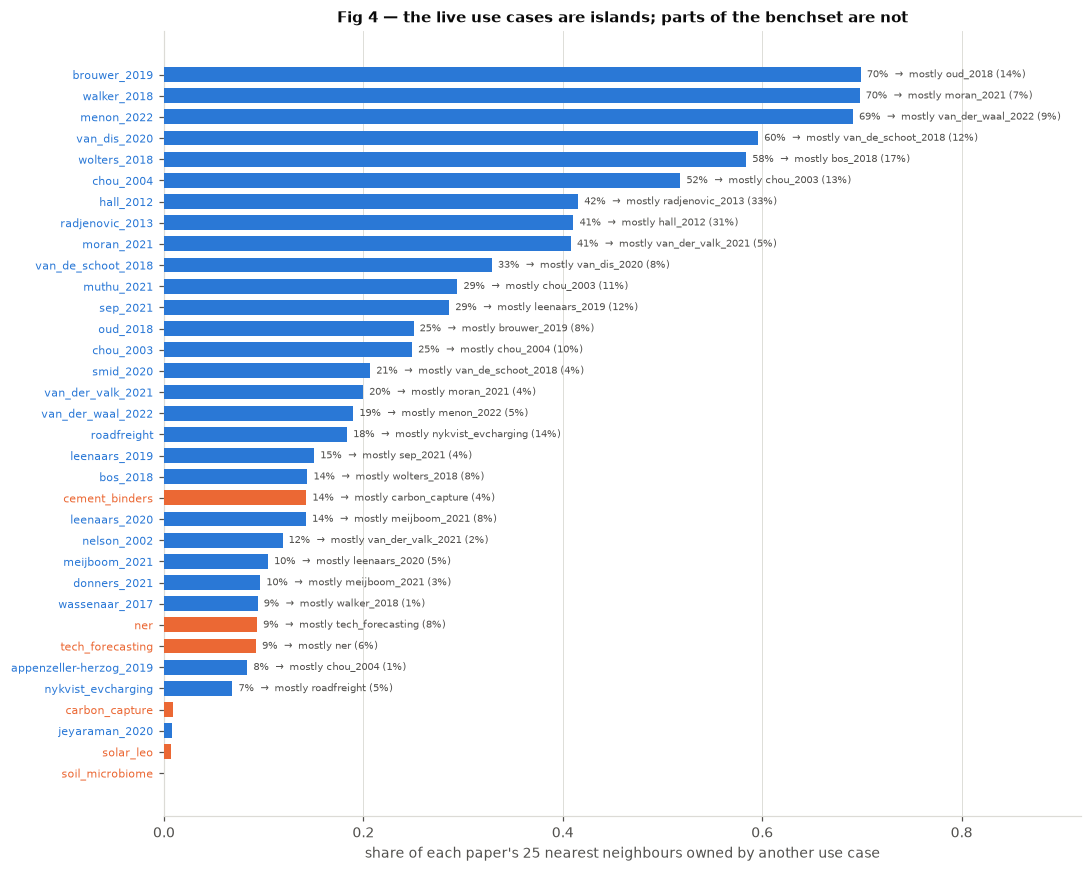

In [8]:
leak = udu.neighbour_leakage(MODEL, k=25).merge(INDEX[["use_case_key", "use_case_name"]], on="use_case_key")
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(leak))[::-1]
ax.barh(y, leak.foreign_frac, color=[SURF[s] for s in leak.surface], height=0.7, zorder=3)
ax.set_yticks(y); ax.set_yticklabels([SHORT[k] for k in leak.use_case_key], fontsize=7.5)
for lab, s in zip(ax.get_yticklabels(), leak.surface): lab.set_color(SURF[s])
for yi, r in zip(y, leak.itertuples()):
    if r.foreign_frac > 0.02:
        ax.annotate(f"{r.foreign_frac:.0%}  →  mostly {SHORT[r.top_neighbour]} ({r.top_neighbour_frac:.0%})",
                    (r.foreign_frac, yi), fontsize=6.8, color=INK2, va="center",
                    xytext=(4, 0), textcoords="offset points")
ax.set(xlim=(0, 0.92), xlabel="share of each paper's 25 nearest neighbours owned by another use case",
       title="Fig 4 — the live use cases are islands; parts of the benchset are not")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [9]:
leak.groupby("surface").foreign_frac.describe()[["count", "mean", "50%", "max"]].round(3)

,count,mean,50%,max
surface,,,,
benchset,28.0,0.294,0.228,0.699
live,6.0,0.057,0.051,0.143


This is the sharpest split in the notebook. Every live TIRI use case is an **island** —
`soil_microbiome` draws 0.03% of its neighbours from elsewhere, `solar_leo` 0.7%,
`carbon_capture` 0.9%. Even the most entangled live use case (`cement_binders`, 14%, mostly
to `carbon_capture`) sits **below the benchset median of 23%**, and the live median (5%) is
about a fifth of it.

The benchset is a different animal: `brouwer_2019` takes **70%** of its neighbours from
other collections, and `hall_2012`/`radjenovic_2013` hand each other roughly a third of
their neighbourhoods. That is 26 SYNERGY reviews drawn from a narrow band of
medicine/psychology/biology, which is exactly what you would expect — and it means the
benchset's 28 collections are *not* 28 independent draws.

## 5. Is this structure real, or is it one model's opinion?

The bake-off cached 11 embedding models on the live corpus. If the similarity structure
were an artefact of Jasper, the models would disagree about it. They do not.

In [10]:
live_keys = INDEX[INDEX.surface == "live"].use_case_key.tolist()
per_model = {}
for mk, meta in udu.MODELS.items():
    c = udu.load_centroids(mk)
    c = c[c.surface == "live"]
    s = udu.centroid_similarity(c, center=True).loc[live_keys, live_keys]
    iu = np.triu_indices(len(live_keys), 1)
    per_model[mk] = s.to_numpy()[iu]
pair_names = [f"{SHORT[live_keys[i]]} / {SHORT[live_keys[j]]}"
              for i, j in zip(*np.triu_indices(len(live_keys), 1))]
P = pd.DataFrame(per_model, index=pair_names)

agree = pd.DataFrame(
    [[spearmanr(P[a], P[b]).statistic for b in P.columns] for a in P.columns],
    index=P.columns, columns=P.columns)
print(f"mean off-diagonal agreement between models (Spearman over the {len(P)} live pairs): "
      f"{offdiag(agree).mean():.3f}")

mean off-diagonal agreement between models (Spearman over the 15 live pairs): 0.906


/var/folders/jj/6k31cm257nd4p_kq2pyxs1sr0000gn/T/ipykernel_2384/3404348967.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


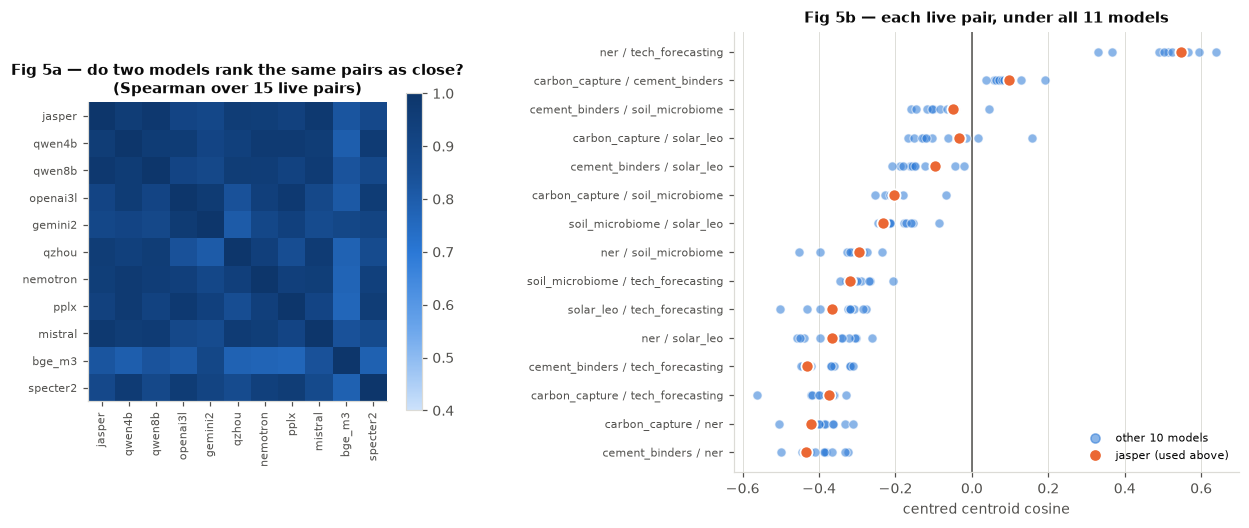

In [11]:
fig = plt.figure(figsize=(13.5, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.62)

ax1 = fig.add_subplot(gs[0]); ax1.grid(False)
im = ax1.imshow(agree, cmap=SEQ, vmin=0.4, vmax=1.0)
ax1.set_xticks(range(len(agree))); ax1.set_yticks(range(len(agree)))
ax1.set_xticklabels(agree.columns, rotation=90, fontsize=7)
ax1.set_yticklabels(agree.index, fontsize=7)
ax1.set_title("Fig 5a — do two models rank the same pairs as close?\n(Spearman over 15 live pairs)")
fig.colorbar(im, ax=ax1, shrink=0.72)

ax2 = fig.add_subplot(gs[1])
row_order = P.median(axis=1).sort_values().index
for i, name in enumerate(row_order):
    vals = P.loc[name]
    ax2.plot(vals, [i] * len(vals), "o", color="#2a78d6", alpha=0.55, markersize=6,
             markeredgecolor="white", markeredgewidth=0.8, zorder=3)
    ax2.plot(vals["jasper"], i, "o", color="#eb6834", markersize=8,
             markeredgecolor="white", markeredgewidth=1.2, zorder=4)
ax2.set_yticks(range(len(row_order))); ax2.set_yticklabels(row_order, fontsize=7.5)
ax2.axvline(0, color=INK2, linewidth=1)
ax2.set(xlabel="centred centroid cosine", title="Fig 5b — each live pair, under all 11 models")
ax2.grid(axis="y", visible=False)
ax2.plot([], [], "o", color="#2a78d6", alpha=0.55, label="other 10 models")
ax2.plot([], [], "o", color="#eb6834", label="jasper (used above)")
ax2.legend(loc="lower right", fontsize=7.5)
plt.tight_layout(); plt.show()

The 11 models agree strongly on *which* use cases are close (mean pairwise Spearman well
above 0.5, most pairs far higher). They disagree on the absolute value — the spread inside
one pair spans a wide band — which is another reason not to read an absolute cosine as a
quantity. **The ordering is a property of the use cases; the number is a property of the
model.** Every claim in this notebook is built on the ordering.

## 6. Functional overlap — does someone else's brief screen my corpus?

Geometry is not the operational question. This one is: take use case A's brief, use it to
rank use case **B**'s papers by cosine, and score that ranking against **B's own labels**.
The diagonal is the zero-label ranker `CONTEXT.md` §2 recommends below ~25 labels. An
off-diagonal cell close to its diagonal means a *foreign brief screens this corpus about as
well as its own*.

This is deliberately the same shape as the shuffled-brief control in
`run_tier1b_control.py`, which `CONTEXT.md` §7 calls the pattern to copy.

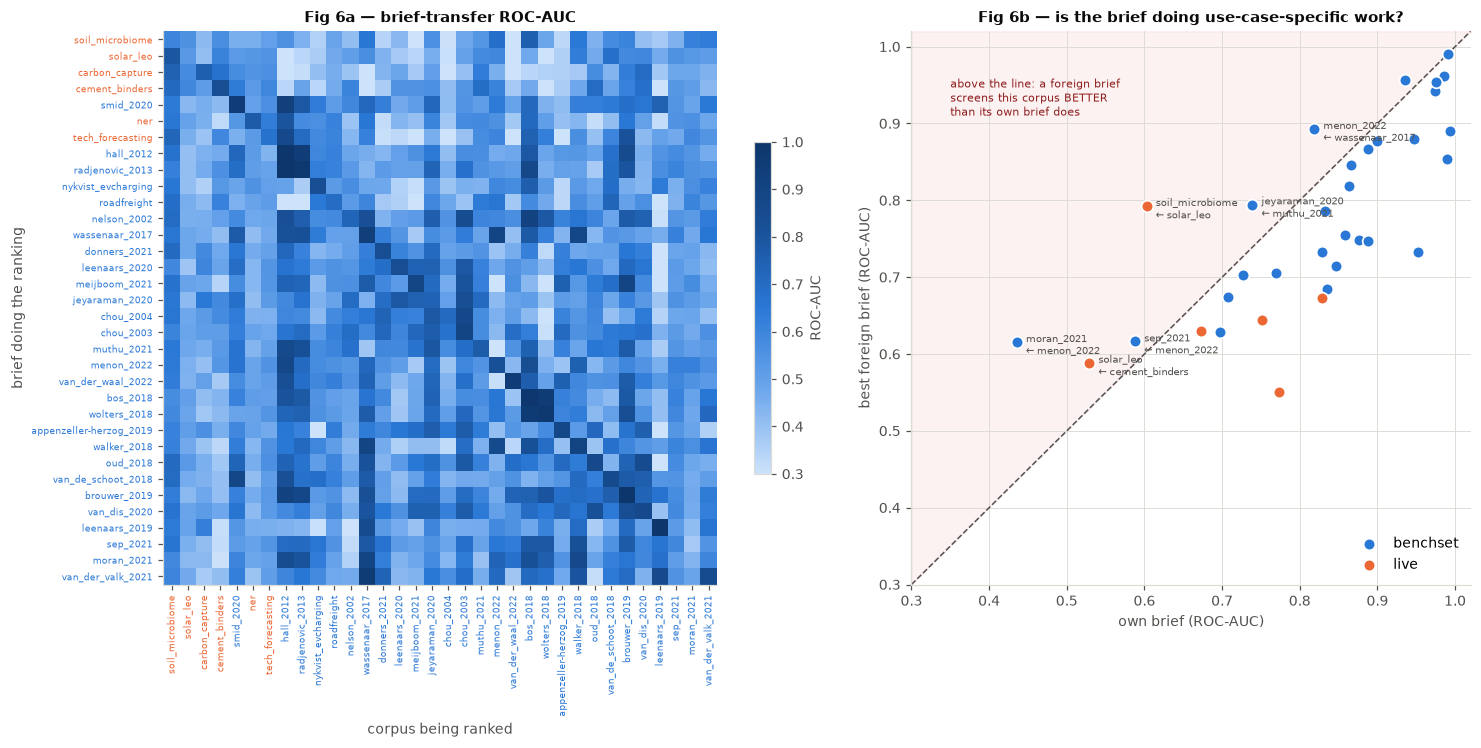

In [12]:
T = udu.brief_transfer_auc(MODEL)          # rows = brief, cols = corpus being ranked
Tord = T.loc[order, order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6.6), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]; ax.grid(False)
im = ax.imshow(Tord, cmap=SEQ, vmin=0.3, vmax=1.0)
ax.set_xticks(range(len(order))); ax.set_yticks(range(len(order)))
ax.set_xticklabels([SHORT[k] for k in order], rotation=90, fontsize=6.2)
ax.set_yticklabels([SHORT[k] for k in order], fontsize=6.2)
for lab, k in zip(ax.get_xticklabels(), order): lab.set_color(SURF[INDEX.set_index("use_case_key").surface[k]])
for lab, k in zip(ax.get_yticklabels(), order): lab.set_color(SURF[INDEX.set_index("use_case_key").surface[k]])
ax.set(xlabel="corpus being ranked", ylabel="brief doing the ranking",
       title="Fig 6a — brief-transfer ROC-AUC")
fig.colorbar(im, ax=ax, shrink=0.6, label="ROC-AUC")

own = pd.Series(np.diag(T), index=T.columns)
off = T.where(~np.eye(len(T), dtype=bool))
best_foreign, who = off.max(axis=0), off.idxmax(axis=0)
ax = axes[1]
for surface, grp in INDEX.set_index("use_case_key").reindex(own.index).groupby("surface"):
    m = own.index.isin(grp.index)
    ax.scatter(own[m], best_foreign[m], s=58, color=SURF[surface], label=surface,
               edgecolors="white", linewidths=1.1, zorder=3)
lims = (0.3, 1.02)
ax.plot(lims, lims, color=INK2, linewidth=1, linestyle="--", zorder=2)
ax.fill_between(lims, lims, 1.02, color="#e34948", alpha=0.07, zorder=1)
ax.annotate("above the line: a foreign brief\nscreens this corpus BETTER\nthan its own brief does",
            (0.35, 0.96), fontsize=7.5, color="#8f1f1f", va="top")
for k in (best_foreign - own).sort_values(ascending=False).head(6).index:
    ax.annotate(f"{SHORT[k]}\n← {SHORT[who[k]]}", (own[k], best_foreign[k]), fontsize=6.5,
                color=INK2, xytext=(6, -8), textcoords="offset points")
ax.set(xlim=lims, ylim=lims, xlabel="own brief (ROC-AUC)", ylabel="best foreign brief (ROC-AUC)",
       title="Fig 6b — is the brief doing use-case-specific work?")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

In [13]:
cmp = pd.DataFrame({"own": own, "best_foreign": best_foreign, "by": who.map(SHORT),
                    "gap": own - best_foreign}).sort_values("gap")
print("Mean own-brief AUC %.3f   |   mean foreign-brief AUC %.3f" % (own.mean(), np.nanmean(off.to_numpy())))
cmp.head(8).round(3).rename(index=SHORT).to_string()

Mean own-brief AUC 0.820   |   mean foreign-brief AUC 0.551


'                   own  best_foreign                 by    gap\nsoil_microbiome  0.603         0.792          solar_leo -0.190\nmoran_2021       0.436         0.616         menon_2022 -0.180\nmenon_2022       0.819         0.893     wassenaar_2017 -0.075\nsolar_leo        0.529         0.588     cement_binders -0.059\njeyaraman_2020   0.739         0.795         muthu_2021 -0.056\nsep_2021         0.588         0.617         menon_2022 -0.029\nwassenaar_2017   0.936         0.956  van_der_valk_2021 -0.020\nhall_2012        0.991         0.990    radjenovic_2013  0.002'

On average briefs are **not** interchangeable — own 0.82 vs foreign 0.55 — which is the
result the query-conditioned block needs, and it holds.

The exceptions are specific and they are the same ones §3 flagged. `hall_2012`'s own brief
scores 0.991; `radjenovic_2013`'s brief scores **0.990** on it. Those two briefs are
functionally the same instrument.

Two rows are a *different* problem and worth separating out: `soil_microbiome` is screened
better by `solar_leo`'s brief (0.792) than by its own (0.603), and `moran_2021` likewise.
That is not use-case overlap — those are use cases whose **own brief is underperforming**,
which is a brief-quality signal for the brief-format experiment, not a diversity finding.

## 7. Does the benchset cover the live use cases?

The benchset is the prevalence-realistic surface (`CONTEXT.md` §4) and the place the 23
ring-fenced reviews live. That only helps if it is *representative* of the silos we
actually ship into.

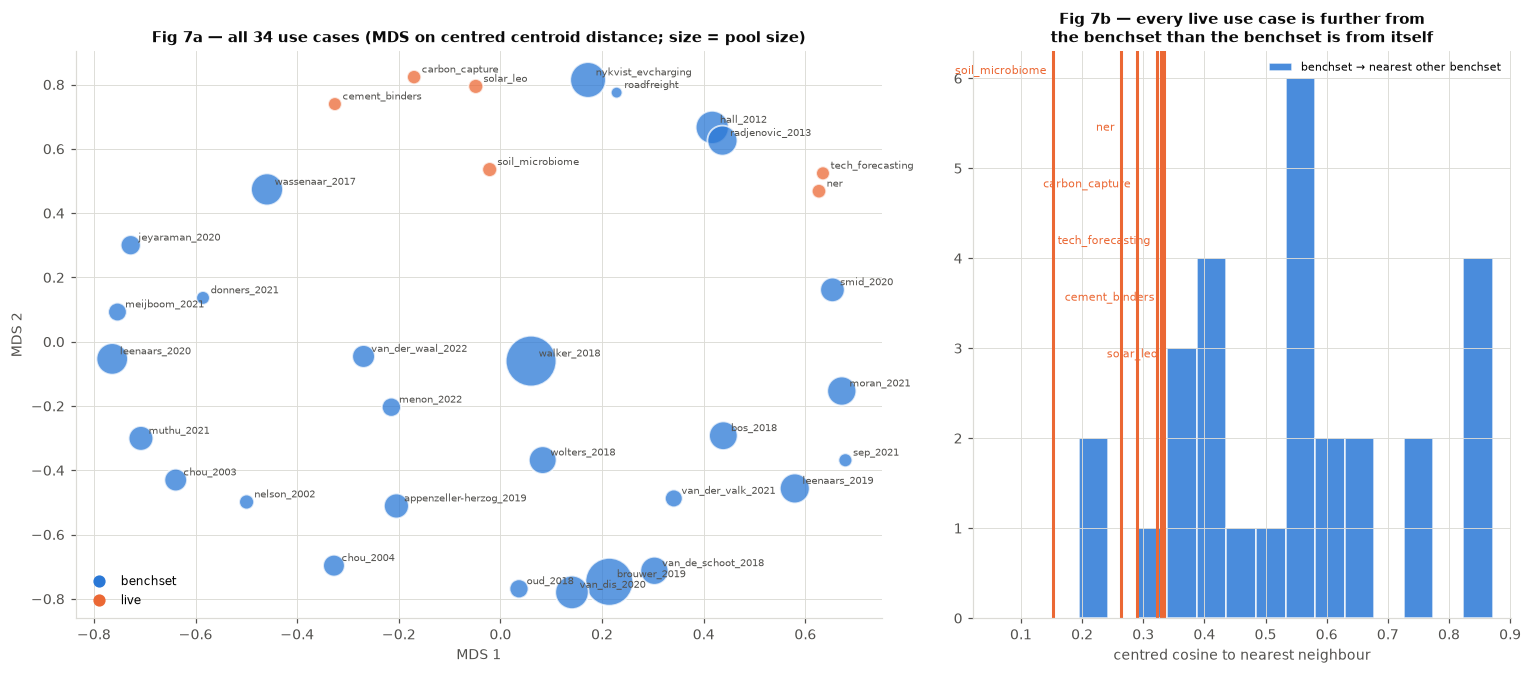

,nearest benchset collection,centred cosine,benchset median nn
carbon_capture,roadfreight,0.290,0.565
cement_binders,wassenaar_2017,0.329,0.565
ner,radjenovic_2013,0.264,0.565
soil_microbiome,roadfreight,0.152,0.565
solar_leo,nykvist_evcharging,0.334,0.565
tech_forecasting,radjenovic_2013,0.322,0.565


In [14]:
from sklearn.manifold import MDS

coords = MDS(n_components=2, dissimilarity="precomputed", random_state=0,
             normalized_stress="auto", n_init=4).fit_transform(D)
xy = pd.DataFrame(coords, index=keys, columns=["x", "y"]).join(INDEX.set_index("use_case_key"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
for surface, grp in xy.groupby("surface"):
    ax.scatter(grp.x, grp.y, s=np.sqrt(grp.n_papers) * 5, color=SURF[surface],
               label=surface, alpha=0.75, edgecolors="white", linewidths=1.2, zorder=3)
for k, r in xy.iterrows():
    ax.annotate(SHORT[k], (r.x, r.y), fontsize=6.8, color=INK2,
                xytext=(5, 3), textcoords="offset points")
ax.set(title="Fig 7a — all 34 use cases (MDS on centred centroid distance; size = pool size)",
       xlabel="MDS 1", ylabel="MDS 2")
ax.legend(handles=[plt.Line2D([], [], marker="o", linestyle="", markersize=7, color=SURF[s], label=s)
                   for s in ("benchset", "live")], loc="lower left", fontsize=8)

# how far is each live use case from its NEAREST benchset collection, vs how far benchset
# collections are from each other
bench_keys = INDEX[INDEX.surface == "benchset"].use_case_key.tolist()
nn_live = sim_cen.loc[live_keys, bench_keys].max(axis=1)
sb = sim_cen.loc[bench_keys, bench_keys]
nn_bench = sb.where(~np.eye(len(sb), dtype=bool)).max(axis=1)

ax = axes[1]
ax.hist(nn_bench, bins=14, color=SURF["benchset"], alpha=0.85, edgecolor="white",
        label="benchset → nearest other benchset")
ax.set_xlim(nn_live.min() - 0.13, max(nn_bench.max(), nn_live.max()) + 0.03)
for i, (k, v) in enumerate(nn_live.sort_values().items()):
    ax.axvline(v, color=SURF["live"], linewidth=2)
    ax.annotate(SHORT[k], (v, ax.get_ylim()[1] * (0.96 - 0.10 * i)), fontsize=7,
                color=SURF["live"], rotation=0, ha="right",
                xytext=(-4, 0), textcoords="offset points")
ax.set(xlabel="centred cosine to nearest neighbour",
       title="Fig 7b — every live use case is further from\nthe benchset than the benchset is from itself")
ax.legend(loc="upper right", fontsize=7.5)
plt.tight_layout(); plt.show()

pd.DataFrame({"nearest benchset collection": sim_cen.loc[live_keys, bench_keys].idxmax(axis=1).map(SHORT),
              "centred cosine": nn_live.round(3),
              "benchset median nn": round(float(nn_bench.median()), 3)}).rename(index=SHORT)

Every live use case sits **further from its nearest benchset collection** than the typical
benchset collection sits from its own nearest neighbour. The benchset is a valid surface for
measuring behaviour *at realistic prevalence* — that is what it was built for — but it is not
a sample from the same topical population as the live silos, and a topic-sensitive default
tuned on it should not be assumed to carry. This is a coverage limitation to state, not a
defect to fix: TIRI use cases are technology/hard-science/industry (`CONTEXT.md` §1), SYNERGY
is medicine/psychology/biology.

## 8. How many *independent* use cases do we actually have?

Participation ratio of the use-case Gram matrix — the same statistic
`latent_space_utils.dispersion_metrics` uses for effective dimensionality. 28 mutually
independent use cases score 28; 28 copies of one score 1.

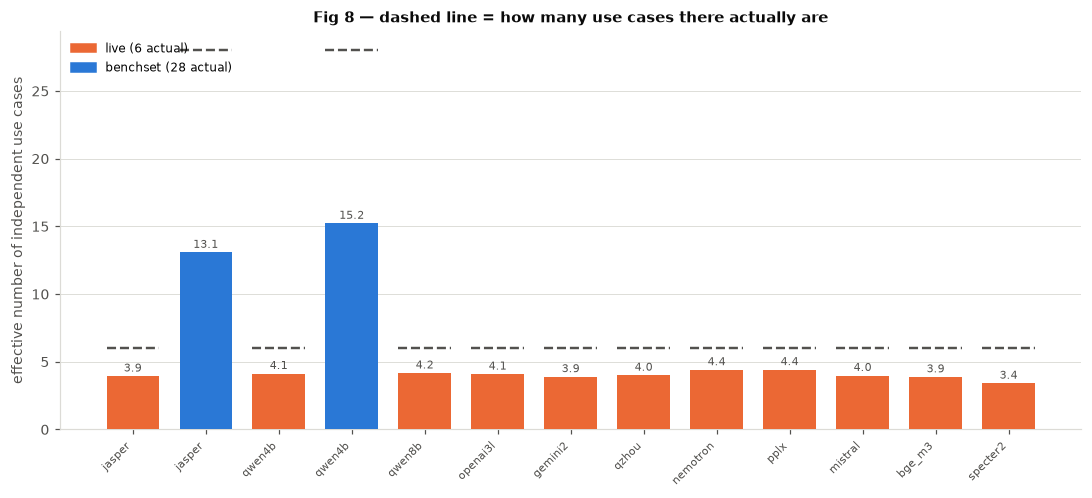

'   model  surface  n  effective_n  fraction\n  jasper     live  6         3.94      0.66\n  jasper benchset 28        13.07      0.47\n  jasper     both 34        13.79      0.41\n  qwen4b     live  6         4.13      0.69\n  qwen4b benchset 28        15.22      0.54\n  qwen4b     both 34        16.85      0.50\n  qwen8b     live  6         4.17      0.69\nopenai3l     live  6         4.09      0.68\n gemini2     live  6         3.90      0.65\n   qzhou     live  6         4.00      0.67\nnemotron     live  6         4.41      0.73\n    pplx     live  6         4.42      0.74\n mistral     live  6         3.98      0.66\n  bge_m3     live  6         3.88      0.65\nspecter2     live  6         3.41      0.57'

In [15]:
rows = []
for mk, meta in udu.MODELS.items():
    c = udu.load_centroids(mk)
    for surface in ("live", "benchset"):
        if surface not in meta["surfaces"]: continue
        s = udu.centroid_similarity(c[c.surface == surface], center=True)
        rows.append(dict(model=mk, surface=surface, n=len(s),
                         effective_n=udu.effective_n_use_cases(s)))
    if len(meta["surfaces"]) == 2:
        s = udu.centroid_similarity(c, center=True)
        rows.append(dict(model=mk, surface="both", n=len(s),
                         effective_n=udu.effective_n_use_cases(s)))
eff = pd.DataFrame(rows)
eff["fraction"] = eff.effective_n / eff.n

fig, ax = plt.subplots(figsize=(10, 4.6))
sub = eff[eff.surface != "both"].copy()
x = np.arange(len(sub))
ax.bar(x, sub.effective_n, color=[SURF[s] for s in sub.surface], zorder=3, width=0.72)
for xi, r in zip(x, sub.itertuples()):
    ax.plot([xi - 0.36, xi + 0.36], [r.n, r.n], color=INK2, linewidth=1.6, linestyle="--", zorder=4)
    ax.annotate(f"{r.effective_n:.1f}", (xi, r.effective_n), ha="center", fontsize=7,
                color=INK2, xytext=(0, 3), textcoords="offset points")
ax.set_xticks(x); ax.set_xticklabels(sub.model, rotation=45, ha="right", fontsize=7.5)
ax.set(ylabel="effective number of independent use cases",
       title="Fig 8 — dashed line = how many use cases there actually are")
ax.grid(axis="x", visible=False)
h = [plt.Rectangle((0, 0), 1, 1, color=SURF[s]) for s in ("live", "benchset")]
ax.legend(h, ["live (6 actual)", "benchset (28 actual)"], loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
eff.round(2).to_string(index=False)

The 6 live use cases are worth **~5.5 of 6** — near-fully independent. The 28 benchset
collections are worth **~12–14 of 28**: roughly half. A 28-fold LOGO mean over the benchset
therefore carries about the evidence of a 13-fold one, and `CONTEXT.md` §5's standing
warning ("six use cases is a small, heterogeneous sample") applies to the benchset harder
than its row count suggests.

## 9. The bias test — does any of this actually inflate LOGO?

Everything above is geometry. This section is the only one that answers the question the
user asked, and it does it two ways:

1. **Correlational** — across the 28 benchset folds, does a use case with a close neighbour
   in the training pool score higher?
2. **Causal** — take the near-twin *out* of the training pool and re-run that fold. This is
   the one that counts; correlation here is badly confounded by prevalence.

Both are run on the LOGO surface `ensemble_eval_utils.logo` already defines, so the fold
construction is the repo's, not a private copy.

In [16]:
import pyarrow.parquet as pq
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

parts = []
for f in ["benchset_v1_small_test", "benchset_v1_large_set_a", "benchset_v1_large_set_b"]:
    p = Path("../../data/processed") / f"{f}.parquet"
    cols = [c for c in pq.ParquetFile(p).schema_arrow.names if c.startswith("lex_")]
    parts.append(pq.read_table(p, columns=cols + ["use_case_key", "y"]).to_pandas())
bench_lex = pd.concat(parts, ignore_index=True)
bench_lex["use_case_key"] = bench_lex.use_case_key.astype(str)
LEX = [c for c in bench_lex.columns if c.startswith("lex_")]

lex_model = lambda: make_pipeline(StandardScaler(),
                                  LogisticRegression(max_iter=2000, class_weight="balanced"))
logo_lex = logo(bench_lex[LEX], bench_lex.y.to_numpy(), bench_lex.use_case_key, lex_model)
print(f"LOGO over {len(logo_lex)} benchset folds, Tier-1b lexical features")
logo_lex[["roc_auc", "pr_auc", "recall_at_10pct"]].round(3).sort_values("roc_auc").to_string()

LOGO over 28 benchset folds, Tier-1b lexical features


'                                 roc_auc  pr_auc  recall_at_10pct\nuse_case                                                         \nsynergy_moran_2021                 0.543   0.036            0.198\nsynergy_menon_2022                 0.552   0.086            0.095\nsynergy_nelson_2002                0.621   0.303            0.162\nroadfreight_metareview             0.643   0.872            0.126\nsynergy_sep_2021                   0.667   0.229            0.150\nnykvist_evcharging                 0.689   0.112            0.305\nsynergy_donners_2021               0.699   0.270            0.357\nsynergy_muthu_2021                 0.707   0.226            0.201\nsynergy_leenaars_2020              0.714   0.165            0.208\nsynergy_chou_2004                  0.723   0.037            0.444\nsynergy_jeyaraman_2020             0.729   0.248            0.365\nsynergy_walker_2018                0.789   0.176            0.532\nsynergy_appenzeller-herzog_2019    0.791   0.040            0

In [17]:
meta = INDEX.set_index("use_case_key")
bias = pd.DataFrame({
    "logo_auc": logo_lex.roc_auc,
    "max_centroid_sim": nn_bench,
    "max_foreign_brief_auc": off.loc[bench_keys, bench_keys].max(axis=0),
    "prevalence": meta.prevalence,
    "n_papers": meta.n_papers,
}).dropna()

def partial_rho(a, b, ctrl):
    ra, rb, rc = rankdata(a), rankdata(b), rankdata(ctrl)
    res = lambda v: v - np.polyval(np.polyfit(rc, v, 1), rc)
    return spearmanr(res(ra), res(rb)).statistic

rng = np.random.default_rng(0)
rows = []
for col in ["max_centroid_sim", "max_foreign_brief_auc", "prevalence", "n_papers"]:
    r = spearmanr(bias[col], bias.logo_auc)
    bs = [spearmanr(*bias.iloc[rng.integers(0, len(bias), len(bias))][[col, "logo_auc"]].values.T).statistic
          for _ in range(2000)]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    rows.append(dict(predictor=col, rho=r.statistic, p=r.pvalue, ci_lo=lo, ci_hi=hi,
                     rho_given_prevalence=np.nan if col == "prevalence"
                     else partial_rho(bias[col], bias.logo_auc, bias.prevalence)))
corr = pd.DataFrame(rows)
corr.round(3).to_string(index=False)

'            predictor    rho     p  ci_lo  ci_hi  rho_given_prevalence\n     max_centroid_sim  0.352 0.067 -0.073  0.681                 0.140\nmax_foreign_brief_auc  0.698 0.000  0.374  0.885                 0.373\n           prevalence -0.723 0.000 -0.846 -0.502                   NaN\n             n_papers  0.453 0.015  0.131  0.744                 0.119'

**The correlational read is inconclusive, and honestly so.** Similarity to the training pool
correlates with LOGO score at rho ≈ +0.35, but the bootstrap CI crosses zero — by
`CONTEXT.md` §5's discipline that is *not established*. Meanwhile **prevalence** correlates
at rho ≈ −0.72: low-prevalence collections score *higher* LOGO ROC-AUC. Controlling for it
drops the similarity correlation to ≈ +0.14.

`max_foreign_brief_auc` correlates strongly (+0.70), but that is partly circular — a corpus
that any brief can rank is a corpus that is intrinsically easy, which lifts its LOGO score
for reasons that have nothing to do with leakage.

So correlation cannot settle it. The causal test can.

In [18]:
# Nearest neighbour of each benchset collection, from the map in §3.
TWINS = sb.where(~np.eye(len(sb), dtype=bool)).idxmax(axis=1)
PROBE = ["synergy_hall_2012", "synergy_radjenovic_2013", "synergy_chou_2003", "synergy_chou_2004",
         "synergy_brouwer_2019", "synergy_van_dis_2020", "synergy_leenaars_2019", "synergy_bos_2018"]

def twin_removal_lexical(uc, twin):
    te = (bench_lex.use_case_key == uc).to_numpy(); yv = bench_lex.y.to_numpy()
    out = {}
    for tag, keep in [("with", ~te), ("without", ~te & (bench_lex.use_case_key != twin).to_numpy())]:
        p = lex_model().fit(bench_lex.loc[keep, LEX], yv[keep]).predict_proba(bench_lex.loc[te, LEX])[:, 1]
        out[tag] = roc_auc_score(yv[te], p)
    return out

lex_rows = [dict(use_case=uc, twin=TWINS[uc], **twin_removal_lexical(uc, TWINS[uc])) for uc in PROBE]
lex_drop = pd.DataFrame(lex_rows).assign(drop=lambda d: d["with"] - d["without"])
lex_drop.assign(use_case=lambda d: d.use_case.map(SHORT), twin=lambda d: d.twin.map(SHORT)).round(3).to_string(index=False)

'       use_case            twin  with  without   drop\n      hall_2012 radjenovic_2013 0.958    0.943  0.015\nradjenovic_2013       hall_2012 0.950    0.932  0.018\n      chou_2003      muthu_2021 0.858    0.864 -0.006\n      chou_2004       chou_2003 0.723    0.722  0.001\n   brouwer_2019    van_dis_2020 0.918    0.924 -0.006\n   van_dis_2020    brouwer_2019 0.843    0.845 -0.002\n  leenaars_2019        sep_2021 0.990    0.989  0.001\n       bos_2018    wolters_2018 0.887    0.902 -0.015'

In [19]:
# Same counterfactual, on EMBEDDING features — the family that reads topic.
# All positives + up to 800 sampled negatives per collection keeps this affordable while
# leaving every positive in play (AUC is unbiased under negative subsampling).
rng = np.random.default_rng(42)
Vs, ys, ucs = [], [], []
for _, m in INDEX[INDEX.surface == "benchset"].iterrows():
    ids, V = udu.load_paper_vectors(MODEL, m.use_case_key, "benchset")
    yv = udu.load_labels(m.use_case_key, "benchset").reindex(ids)
    keep = yv.notna().to_numpy(); V, yv = V[keep], yv[keep].to_numpy().astype(int)
    take = np.concatenate([np.where(yv == 1)[0], rng.permutation(np.where(yv == 0)[0])[:800]])
    Vs.append(V[take]); ys.append(yv[take]); ucs += [m.use_case_key] * len(take)
Vemb = np.vstack(Vs).astype(np.float32); yemb = np.concatenate(ys); ucemb = np.array(ucs)

emb_model = lambda: make_pipeline(PCA(n_components=64, random_state=0), StandardScaler(),
                                  LogisticRegression(max_iter=3000, class_weight="balanced"))
def twin_removal_embedding(uc, twin):
    te = ucemb == uc; out = {}
    for tag, keep in [("with", ~te), ("without", ~te & (ucemb != twin))]:
        p = emb_model().fit(Vemb[keep], yemb[keep]).predict_proba(Vemb[te])[:, 1]
        out[tag] = roc_auc_score(yemb[te], p)
    return out

emb_drop = pd.DataFrame([dict(use_case=uc, twin=TWINS[uc], **twin_removal_embedding(uc, TWINS[uc]))
                         for uc in PROBE]).assign(drop=lambda d: d["with"] - d["without"])
emb_drop.assign(use_case=lambda d: d.use_case.map(SHORT), twin=lambda d: d.twin.map(SHORT)).round(3).to_string(index=False)

'       use_case            twin  with  without   drop\n      hall_2012 radjenovic_2013 0.828    0.537  0.291\nradjenovic_2013       hall_2012 0.914    0.588  0.326\n      chou_2003      muthu_2021 0.803    0.852 -0.049\n      chou_2004       chou_2003 0.603    0.607 -0.004\n   brouwer_2019    van_dis_2020 0.725    0.743 -0.018\n   van_dis_2020    brouwer_2019 0.504    0.491  0.013\n  leenaars_2019        sep_2021 0.225    0.230 -0.005\n       bos_2018    wolters_2018 0.874    0.869  0.005'

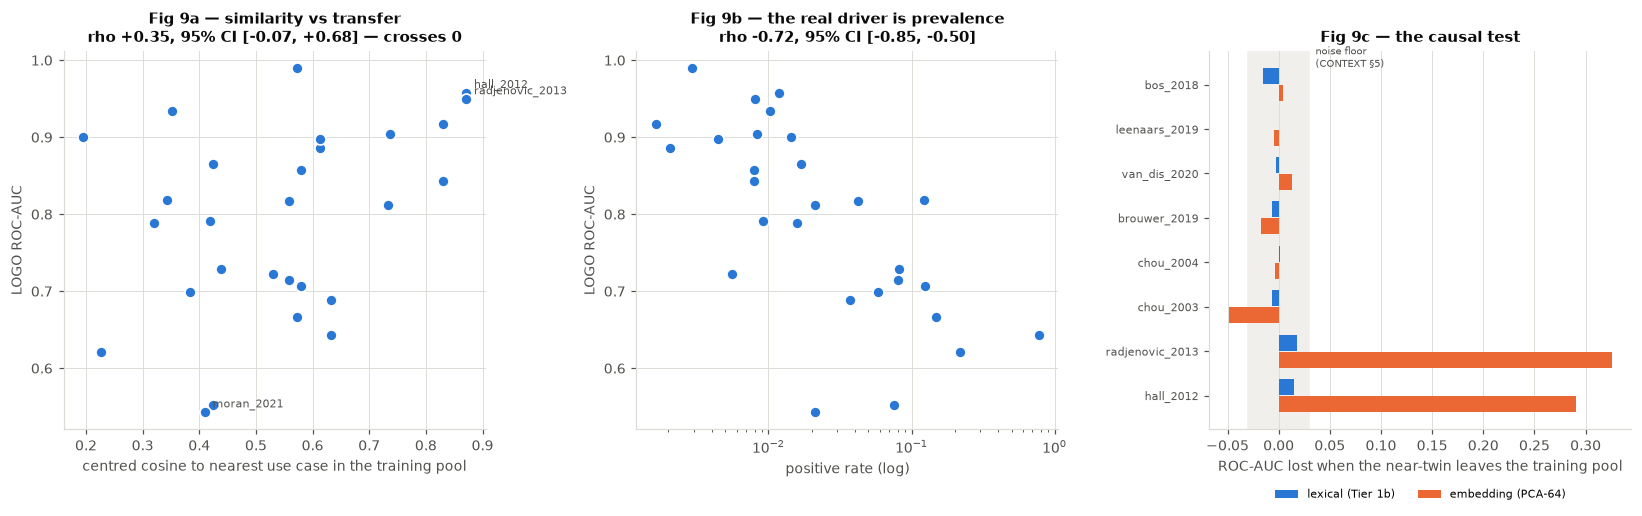

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

ax = axes[0]
ax.scatter(bias.max_centroid_sim, bias.logo_auc, s=52, color=SURF["benchset"],
           edgecolors="white", linewidths=1.1, zorder=3)
for k in ["synergy_hall_2012", "synergy_radjenovic_2013", "synergy_moran_2021"]:
    ax.annotate(SHORT[k], (bias.max_centroid_sim[k], bias.logo_auc[k]), fontsize=7,
                color=INK2, xytext=(5, 3), textcoords="offset points")
r0 = corr.set_index("predictor").loc["max_centroid_sim"]
ax.set(xlabel="centred cosine to nearest use case in the training pool", ylabel="LOGO ROC-AUC",
       title=f"Fig 9a — similarity vs transfer\nrho {r0.rho:+.2f}, 95% CI [{r0.ci_lo:+.2f}, {r0.ci_hi:+.2f}] — crosses 0")

ax = axes[1]
ax.scatter(bias.prevalence, bias.logo_auc, s=52, color=SURF["benchset"],
           edgecolors="white", linewidths=1.1, zorder=3)
r1 = corr.set_index("predictor").loc["prevalence"]
ax.set(xscale="log", xlabel="positive rate (log)", ylabel="LOGO ROC-AUC",
       title=f"Fig 9b — the real driver is prevalence\nrho {r1.rho:+.2f}, 95% CI [{r1.ci_lo:+.2f}, {r1.ci_hi:+.2f}]")

ax = axes[2]
yy = np.arange(len(PROBE))
ax.barh(yy + 0.19, lex_drop["drop"], height=0.36, color="#2a78d6", label="lexical (Tier 1b)", zorder=3)
ax.barh(yy - 0.19, emb_drop["drop"], height=0.36, color="#eb6834", label="embedding (PCA-64)", zorder=3)
ax.axvspan(-0.03, 0.03, color="#f0efec", zorder=1)
ax.annotate("noise floor\n(CONTEXT §5)", (0.03, len(PROBE) - 0.6), fontsize=6.8, color=INK2,
            xytext=(4, 0), textcoords="offset points")
ax.set_yticks(yy); ax.set_yticklabels([SHORT[u] for u in PROBE], fontsize=7.5)
ax.set(xlabel="ROC-AUC lost when the near-twin leaves the training pool",
       title="Fig 9c — the causal test")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncols=2, fontsize=7.5)
plt.tight_layout(); plt.show()

**Fig 9c is the answer.**

- On the **lexical / brief-relative** family, removing a use case's nearest twin from the
  training pool changes its LOGO score by at most **0.018** — inside the ±0.03 noise floor,
  and negative as often as positive. No measurable leakage.
- On the **embedding** family, removing `radjenovic_2013` costs `hall_2012` **0.291
  ROC-AUC** (0.828 → 0.537), and the reverse costs **0.326** (0.914 → 0.588). Ten times the
  noise floor. Without its twin, the embedding model on that fold is at chance.
- Every other probed pair moves within noise on both families.

The mechanism is exactly `CONTEXT.md` §2. Embeddings encode *which use case this is*, so an
embedding LOGO fold with a near-duplicate in the pool is scoring topic recognition, not
transfer. Brief-relative features never read topic, so topic overlap gives them nothing to
cheat with — the property that makes them transfer is the same property that makes them
immune to this.

## 10. What this means

**How similar are the use cases?**

- The 6 live TIRI use cases are **effectively independent** — 5.5 of 6 by participation
  ratio, and each is a topical island (≤0.9% of its papers' nearest neighbours come from
  another use case). Whatever else is wrong with a 6-use-case sample, redundancy is not it.
- The 28 benchset collections are worth **~12–14 independent ones**. One pair
  (`hall_2012` / `radjenovic_2013`) is a genuine near-duplicate: 0.87 centred centroid
  cosine against a 0.987 centred ceiling, a third of each other's nearest neighbours, and briefs
  that screen each other's corpora at 0.990 vs 0.991 own-brief.
- The structure is **not an artefact of one embedding model** — all 11 cached models agree
  on the ordering of close pairs, while disagreeing on absolute values. Read orderings, not
  cosines.

**Does it bias the ensemble?** Split the question by what is being decided:

| Decision surface | Biased? | Basis |
|---|---|---|
| **Per-silo production models** | **No.** Silos never see each other's data. | `CONTEXT.md` §1 |
| **LOGO defaults selection using brief-relative / lexical features** | **No measurable bias.** Twin removal costs ≤0.018, inside noise. | §9c |
| **LOGO defaults selection using embedding features** | **Yes, badly, on one pair.** Twin removal costs 0.29–0.33 ROC-AUC. | §9c |
| **Any headline mean over the 28 benchset folds** | **Overstated confidence.** 28 folds carry ~13 folds of evidence. | §8 |
| **Benchset as a proxy for live silos** | **Topically, no.** Every live use case is further from the benchset than the benchset is from itself. | §7 |

**What I would actually change**

1. **Never report an embedding-arm LOGO number for `hall_2012` or `radjenovic_2013` with
   the other in the pool.** Either drop one of the pair from the LOGO loop or report both
   with the twin excluded. As it stands those two folds flatter the embedding arm by ~0.3
   AUC each, on 2 of 28 folds — enough to move a mean that decisions get made on.
2. **Quote the effective fold count next to any benchset LOGO mean** (`~13`, not `28`), and
   widen the noise floor accordingly. This compounds the selection-on-holdout risk already
   logged in `CONTEXT.md` §4.
3. **Check the 23 ring-fenced reviews for twins against the 5 already used** before
   spending them — the map in §3 is the tool, and it is cheap to re-run.
4. **Treat `soil_microbiome` and `moran_2021` as a brief-quality item, not a diversity one**
   (§6): a foreign brief outranks their own. That belongs in the brief-format experiment.
5. **Don't generalise the clean lexical result.** It was measured on this feature family, on
   this surface, with LogisticRegression. Any *new* feature family that reads topic
   re-opens the question, and §9's twin-removal probe is the check to re-run.

**What this notebook does not establish.** The causal test probes 8 folds, not all 28, and
one embedding configuration (PCA-64 + LogReg on Jasper). The correlational read is
underpowered at n=28 and heavily confounded by prevalence. And this measures leakage
*between* use cases — it says nothing about label recall inside one, which `CONTEXT.md` §4
still lists as open.